In [1]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Definindo semente

In [3]:
#instalação das bibliotecas não nativas no Colab
!pip install boruta shap
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.0 MB/s eta 0:00:00


In [4]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [5]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [6]:
# Instalando pacotes

In [7]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install imbalanced-learn
!pip install pycalib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.4/612.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycalib: filename=pycalib-0.1.0.dev6-py3-none-any.whl size=37283 sha256=04e0cab654967c77d378ae0d522445e04a235aedf22b21975af21ada19dbc5bb
  Stored in directory: /root/.cache/pip/wheels/ec/b5/10/93c91bf324e855f115998634a7f6091b62d7a6a32d6e62c05b
Successfully built pycalib


In [8]:
# Carregando pacotes

In [9]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

#Etapa1

In [10]:
import pandas as pd

In [11]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_xgb1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_xgb1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [12]:
df_train.shape

(18306, 26)

In [13]:
df_test.shape

(7324, 26)

In [14]:
df_train.columns

Index(['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'cs_raca_2.0',
       'raiox_tora_4.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravdiabe_1.0',
       'bacilosc_e_3.0', 'pop_liber_1.0', 'pop_rua_1.0', 'benef_gov_9.0',
       'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0',
       'escola_faixa_0.0', 'escola_faixa_1.0', 'escola_faixa_9.0',
       'faixa_etaria_1.0', 'agravalcoo_9.0', 'benef_gov_0.0',
       'faixa_etaria_0.0', 'faixa_etaria_2.0', 'cura'],
      dtype='object')

In [15]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

In [16]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=False)

,count
cura,
1,14712
0,3594


In [17]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.803671
0,0.196329


In [18]:
#Visualização da proporção do desfecho na base de treino
y_test.value_counts(normalize=False)

,count
cura,
1,6086
0,1238


In [19]:
#Visualização da proporção do desfecho na base de treino
y_test.value_counts(normalize=True)

,proportion
cura,
1,0.830967
0,0.169033


In [20]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb_novo.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [21]:
data = joblib.load(caminho)

xgb = data["model_xgb_novo"]
print(data["params_xgb_novo"])
print(data["method_xgb_novo"])

{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.06193785329107693, 'subsample': 0.8648682549169897, 'colsample_bytree': 0.6495150359640375, 'gamma': 0.1861675099363223, 'reg_alpha': 0.0021545465077712276, 'reg_lambda': 1.7162020163560698}
Optuna


In [22]:
from xgboost import XGBClassifier

# ===============================
# Criar DataFrame final de AUCs
# ===============================

params_xgb = data["params_xgb_novo"]

xgb = XGBClassifier(
    **params_xgb,
    **({"random_state": seed}
       if "random_state" not in params_xgb
       else {})
)



In [23]:
X_train = df_train.drop(columns=['cura'])
y_train = df_train['cura']

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6495150359640375, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.1861675099363223, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.06193785329107693,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [24]:
print(X_train.shape)
print(y_train.shape)
print(y_train.value_counts(normalize=True))

(18306, 25)
(18306,)
cura
1    0.803671
0    0.196329
Name: proportion, dtype: float64


AUC = 0.722


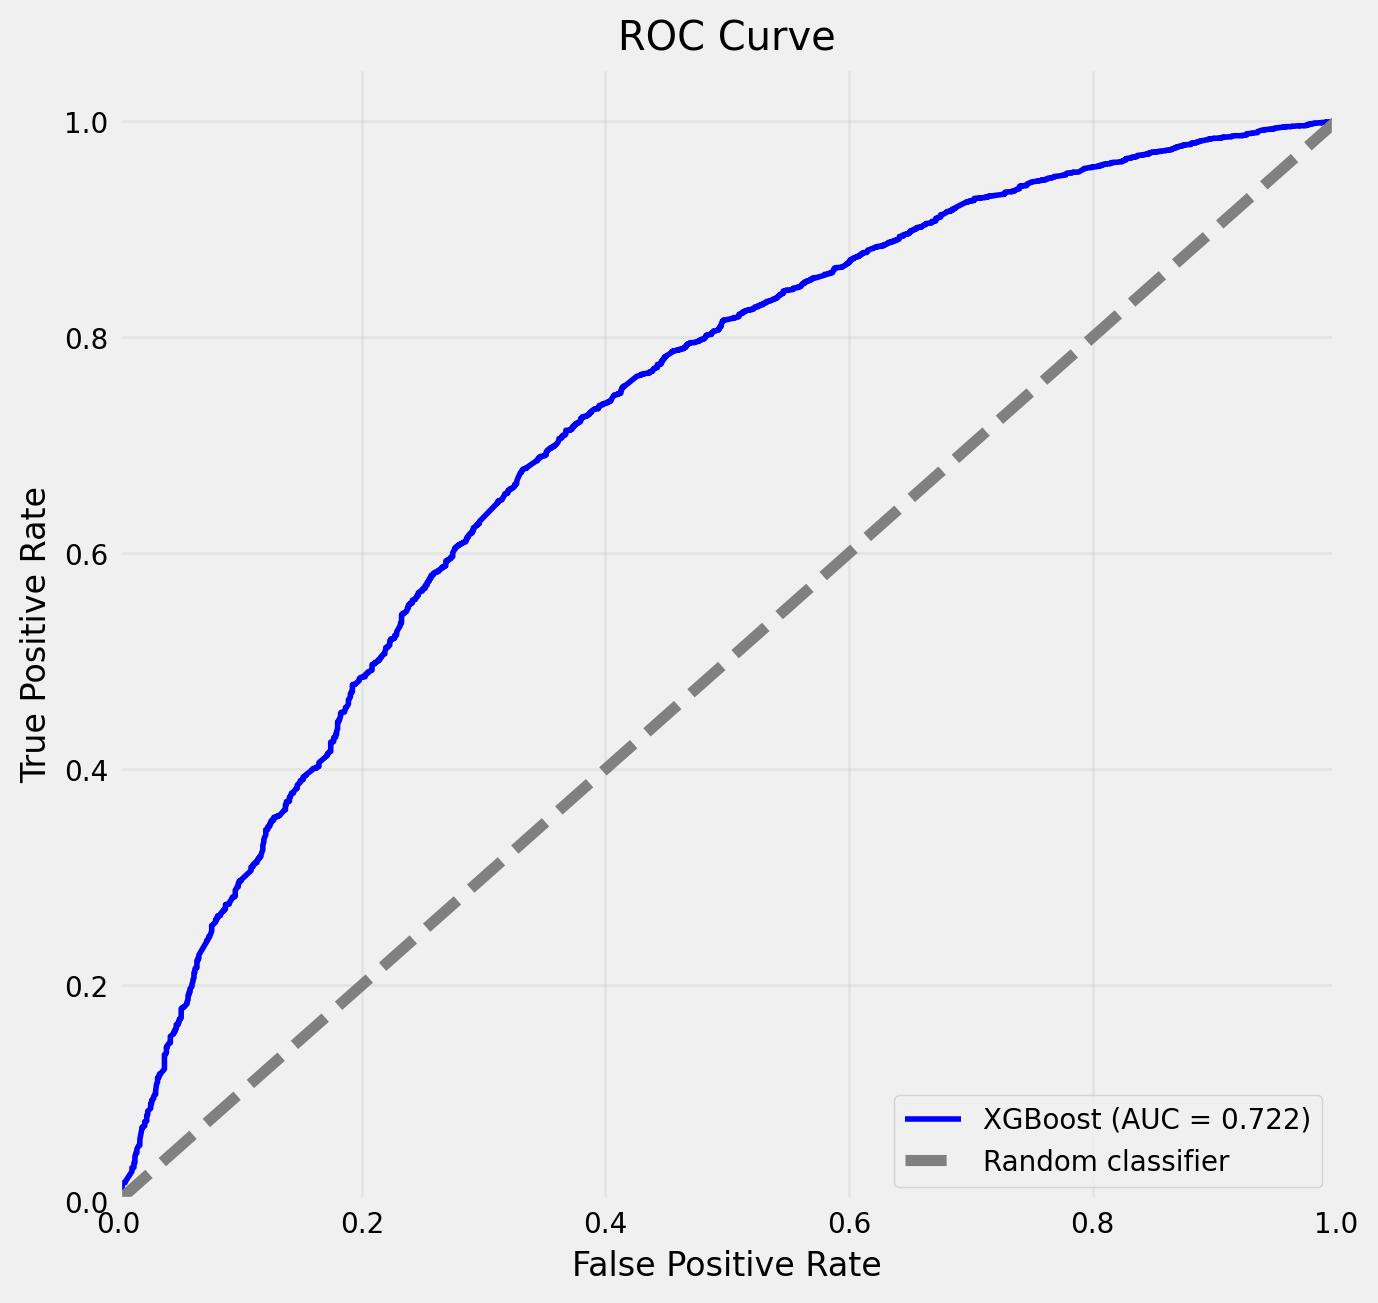

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ==========================
# Conjunto de teste
# ==========================

X_test = df_test.drop(columns=['cura'])
y_test = df_test['cura']

# ==========================
# Probabilidades previstas
# ==========================

y_pred_prob = xgb.predict_proba(X_test)[:, 1]

# ==========================
# Curva ROC
# ==========================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC = {roc_auc:.3f}")

# ==========================
# Gráfico
# ==========================

plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    color="blue",
    lw=2,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

Brier Score = 0.1265


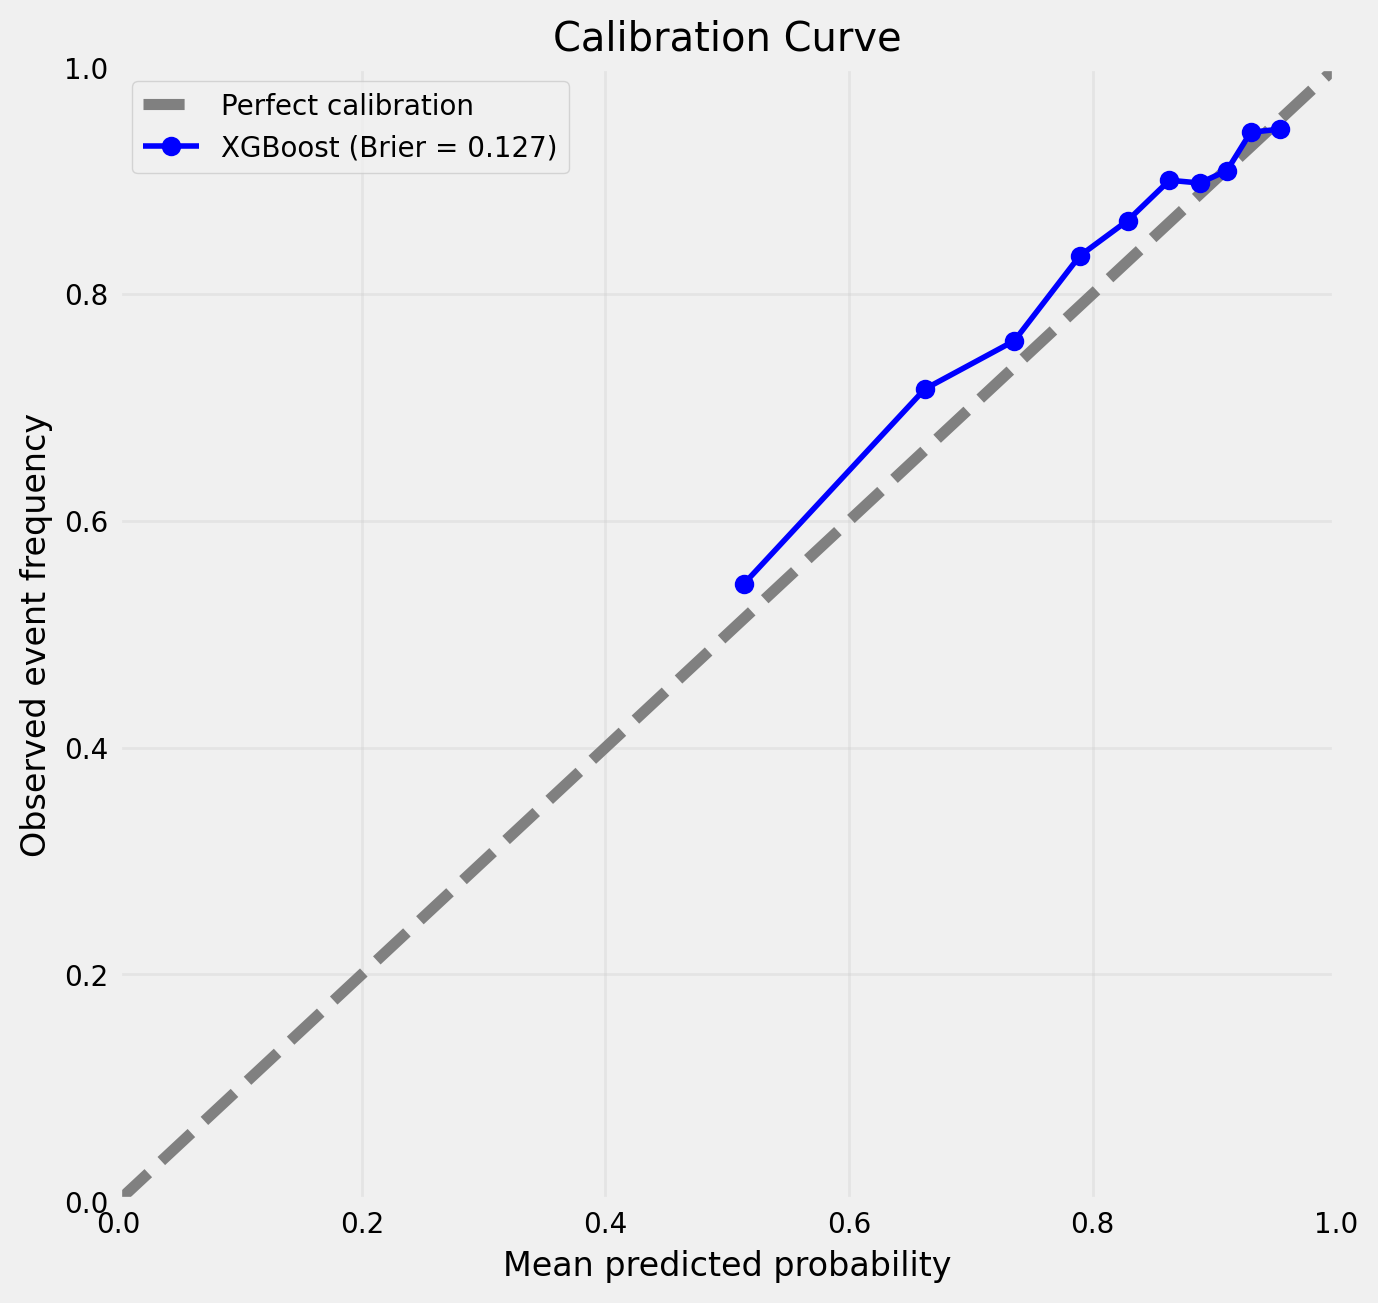

In [26]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# ==========================
# Probabilidades previstas
# ==========================

y_pred_prob = xgb.predict_proba(X_test)[:, 1]

# ==========================
# Curva de calibração
# ==========================

frac_pos, mean_pred = calibration_curve(
    y_test,
    y_pred_prob,
    n_bins=10,
    strategy="quantile"   # também pode usar "uniform"
)

# ==========================
# Brier Score
# ==========================

brier = brier_score_loss(y_test, y_pred_prob)
print(f"Brier Score = {brier:.4f}")

# ==========================
# Gráfico
# ==========================

plt.figure(figsize=(7,7))

# Calibração perfeita
plt.plot([0,1], [0,1],
         linestyle='--',
         color='gray',
         label='Perfect calibration')

# Modelo
plt.plot(mean_pred,
         frac_pos,
         marker='o',
         linewidth=2,
         color='blue',
         label=f'XGBoost (Brier = {brier:.3f})')

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event frequency")
plt.title("Calibration Curve")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [27]:
print(X_test.shape)

print(y_test.shape)

(7324, 25)
(7324,)


Criando cutoffs

In [28]:
cutoff_prev = y_train.mean()
print(cutoff_prev)

from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_train, xgb.predict_proba(X_train_novo)[:,1])

youden = tpr - fpr

idx = np.argmax(youden)

cutoff_youden = thresholds[idx]

print(cutoff_youden)

from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(
    y_train,
    xgb.predict_proba(X_train_novo)[:,1]
)

idx = np.where(tpr >= 0.95)[0][0]

cutoff_clinico = thresholds[idx]

print(cutoff_clinico)

0.8036709275647329
0.7846539
0.59605277


###Freq

In [29]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample

# --------------------------------------------------
# Probabilidades da classe positiva
# --------------------------------------------------
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# --------------------------------------------------
# AUC e ponto de corte
# --------------------------------------------------
auc = roc_auc_score(y_test, y_prob)

cutoff = cutoff_prev
y_pred = (y_prob >= cutoff).astype(int)

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# --------------------------------------------------
# Métricas
# --------------------------------------------------
sensibilidade = tp / (tp + fn)
especificidade = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

# --------------------------------------------------
# Bootstrap IC95%
# --------------------------------------------------
n_boot = 2000

aucs = []
sens = []
esp = []
vpps = []
vpns = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_true_b = y_test_np[idx]
    y_prob_b = y_prob_np[idx]

    # Necessário para cálculo da AUC
    if len(np.unique(y_true_b)) < 2:
        continue

    aucs.append(
        roc_auc_score(y_true_b, y_prob_b)
    )

    y_pred_b = (y_prob_b >= cutoff).astype(int)

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_true_b,
        y_pred_b,
        labels=[0, 1]
    ).ravel()

    sens.append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan)
    esp.append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan)
    vpps.append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan)
    vpns.append(tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan)


def ic95(x):
    return np.nanpercentile(x, [2.5, 97.5])

auc_ic = ic95(aucs)
sens_ic = ic95(sens)
esp_ic = ic95(esp)
vpp_ic = ic95(vpps)
vpn_ic = ic95(vpns)

print("\n==============================")
print("DESFECHO: CURA")
print("==============================")
print(f"Critério do cutoff: {cutoff_prev}")
print(f"Cutoff utilizado : {cutoff:.4f}\n")

print(f"AUC-ROC       : {auc:.4f} ({auc_ic[0]:.4f} - {auc_ic[1]:.4f})")
print(f"Sensibilidade : {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"Especificidade: {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"VPP           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")
print(f"VPN           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")

print("\n==============================")
print("DESFECHO: NÃO CURA")
print("==============================")
print(f"Critério do cutoff: {cutoff_prev}")
print(f"Cutoff utilizado : {cutoff:.4f}\n")

print(f"Sensibilidade : {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"Especificidade: {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"VPP           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")
print(f"VPN           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
print("\n==============================")
print("MATRIZ DE CONFUSÃO")
print("==============================")

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


DESFECHO: CURA
Critério do cutoff: 0.8036709275647329
Cutoff utilizado : 0.8037

AUC-ROC       : 0.7225 (0.7060 - 0.7380)
Sensibilidade : 0.6872 (0.6757 - 0.6982)
Especificidade: 0.6551 (0.6291 - 0.6809)
VPP           : 0.9074 (0.8991 - 0.9155)
VPN           : 0.2987 (0.2813 - 0.3157)

DESFECHO: NÃO CURA
Critério do cutoff: 0.8036709275647329
Cutoff utilizado : 0.8037

Sensibilidade : 0.6551 (0.6291 - 0.6809)
Especificidade: 0.6872 (0.6757 - 0.6982)
VPP           : 0.2987 (0.2813 - 0.3157)
VPN           : 0.9074 (0.8991 - 0.9155)

MATRIZ DE CONFUSÃO
TN = 811
FP = 427
FN = 1904
TP = 4182


In [30]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

# Probabilidades da classe positiva
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Ponto de corte
cutoff = cutoff_prev

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Métricas
sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Preditivo Positivo
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Preditivo Negativo

# Resultados
print(f"AUC-ROC       : {auc:.4f}")
print(f"Sensibilidade : {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"VPP           : {vpp:.4f}")
print(f"VPN           : {vpn:.4f}")

print("\nMatriz de Confusão")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

AUC-ROC       : 0.7225
Sensibilidade : 0.6872
Especificidade: 0.6551
VPP           : 0.9074
VPN           : 0.2987

Matriz de Confusão
TN = 811
FP = 427
FN = 1904
TP = 4182


In [31]:
from sklearn.metrics import confusion_matrix

# Probabilidades
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# Ponto de corte
cutoff = cutoff_prev

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 811  427]
 [1904 4182]]


In [32]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Linhas = Predito | Colunas = Real
matriz_invertida = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predito 1", "Predito 0"],
    columns=["Real 1", "Real 0"]
)

print(matriz_invertida)

           Real 1  Real 0
Predito 1    4182     427
Predito 0    1904     811


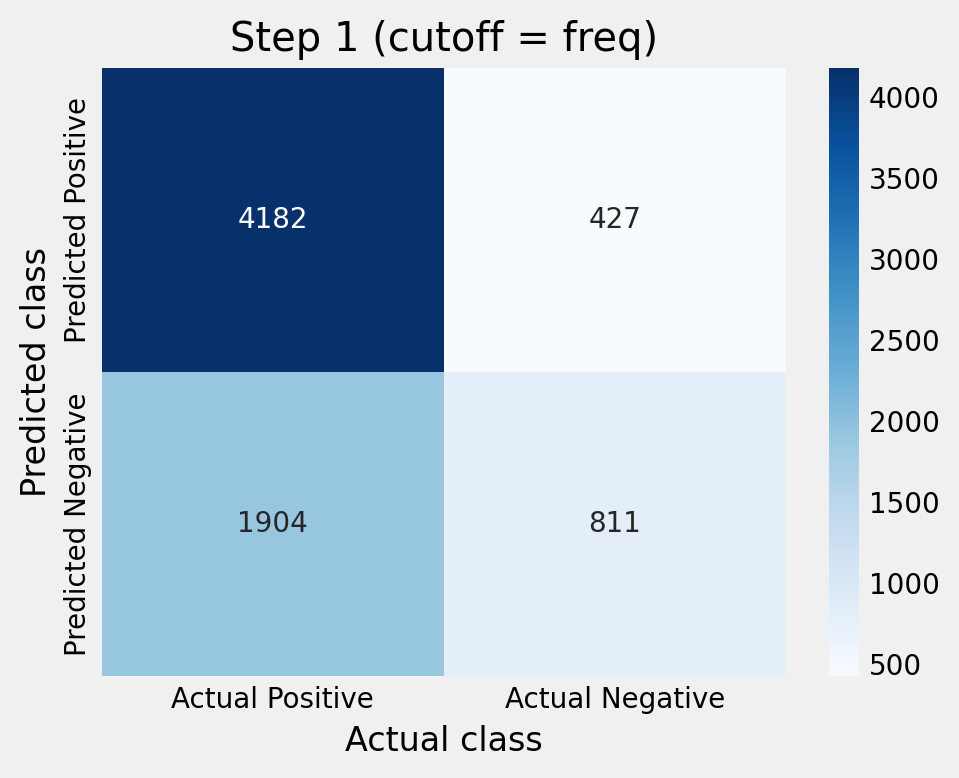

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Rows = Predicted | Columns = Actual
confusion_matrix_df = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predicted Positive", "Predicted Negative"],
    columns=["Actual Positive", "Actual Negative"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Step 1 (cutoff = freq)")
plt.xlabel("Actual class")
plt.ylabel("Predicted class")

plt.tight_layout()

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/confusion_matrixt1_freq.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Youden

In [34]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample

# --------------------------------------------------
# Probabilidades da classe positiva
# --------------------------------------------------
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# --------------------------------------------------
# AUC e ponto de corte
# --------------------------------------------------
auc = roc_auc_score(y_test, y_prob)

cutoff = cutoff_youden
y_pred = (y_prob >= cutoff).astype(int)

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# --------------------------------------------------
# Métricas
# --------------------------------------------------
sensibilidade = tp / (tp + fn)
especificidade = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

# --------------------------------------------------
# Bootstrap IC95%
# --------------------------------------------------
n_boot = 2000

aucs = []
sens = []
esp = []
vpps = []
vpns = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_true_b = y_test_np[idx]
    y_prob_b = y_prob_np[idx]

    # Necessário para cálculo da AUC
    if len(np.unique(y_true_b)) < 2:
        continue

    aucs.append(
        roc_auc_score(y_true_b, y_prob_b)
    )

    y_pred_b = (y_prob_b >= cutoff).astype(int)

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_true_b,
        y_pred_b,
        labels=[0, 1]
    ).ravel()

    sens.append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan)
    esp.append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan)
    vpps.append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan)
    vpns.append(tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan)


def ic95(x):
    return np.nanpercentile(x, [2.5, 97.5])

auc_ic = ic95(aucs)
sens_ic = ic95(sens)
esp_ic = ic95(esp)
vpp_ic = ic95(vpps)
vpn_ic = ic95(vpns)

print("\n==============================")
print("DESFECHO: CURA")
print("==============================")
print(f"Critério do cutoff: {cutoff_youden}")
print(f"Cutoff utilizado : {cutoff:.4f}\n")

print(f"AUC-ROC       : {auc:.4f} ({auc_ic[0]:.4f} - {auc_ic[1]:.4f})")
print(f"Sensibilidade : {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"Especificidade: {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"VPP           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")
print(f"VPN           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")

print("\n==============================")
print("DESFECHO: NÃO CURA")
print("==============================")
print(f"Critério do cutoff: {cutoff_youden}")
print(f"Cutoff utilizado : {cutoff:.4f}\n")

print(f"Sensibilidade : {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"Especificidade: {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"VPP           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")
print(f"VPN           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
print("\n==============================")
print("MATRIZ DE CONFUSÃO")
print("==============================")

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


DESFECHO: CURA
Critério do cutoff: 0.784653902053833
Cutoff utilizado : 0.7847

AUC-ROC       : 0.7225 (0.7070 - 0.7382)
Sensibilidade : 0.7174 (0.7061 - 0.7286)
Especificidade: 0.6268 (0.5989 - 0.6540)
VPP           : 0.9043 (0.8955 - 0.9127)
VPN           : 0.3109 (0.2923 - 0.3289)

DESFECHO: NÃO CURA
Critério do cutoff: 0.784653902053833
Cutoff utilizado : 0.7847

Sensibilidade : 0.6268 (0.5989 - 0.6540)
Especificidade: 0.7174 (0.7061 - 0.7286)
VPP           : 0.3109 (0.2923 - 0.3289)
VPN           : 0.9043 (0.8955 - 0.9127)

MATRIZ DE CONFUSÃO
TN = 776
FP = 462
FN = 1720
TP = 4366


In [35]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

# Probabilidades da classe positiva
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Ponto de corte
cutoff = cutoff_youden

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Métricas
sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Preditivo Positivo
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Preditivo Negativo

# Resultados
print(f"AUC-ROC       : {auc:.4f}")
print(f"Sensibilidade : {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"VPP           : {vpp:.4f}")
print(f"VPN           : {vpn:.4f}")

print("\nMatriz de Confusão")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

AUC-ROC       : 0.7225
Sensibilidade : 0.7174
Especificidade: 0.6268
VPP           : 0.9043
VPN           : 0.3109

Matriz de Confusão
TN = 776
FP = 462
FN = 1720
TP = 4366


In [36]:
from sklearn.metrics import confusion_matrix

# Probabilidades
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# Ponto de corte
cutoff = cutoff_youden

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 776  462]
 [1720 4366]]


In [37]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Linhas = Predito | Colunas = Real
matriz_invertida = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predito 1", "Predito 0"],
    columns=["Real 1", "Real 0"]
)

print(matriz_invertida)

           Real 1  Real 0
Predito 1    4366     462
Predito 0    1720     776


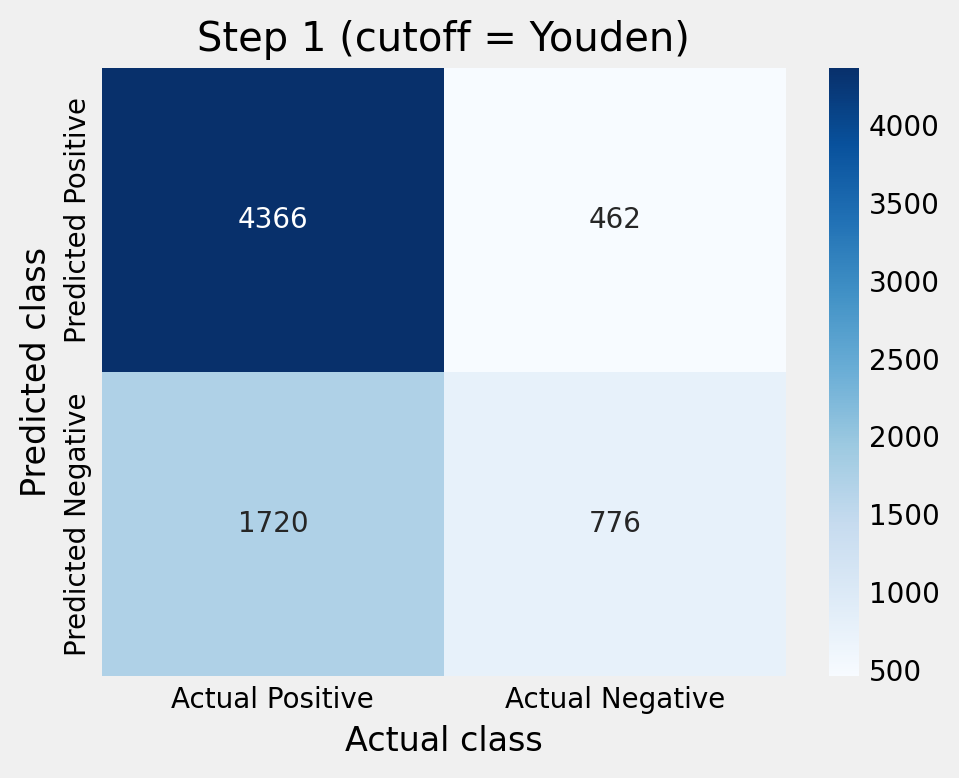

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Rows = Predicted | Columns = Actual
confusion_matrix_df = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predicted Positive", "Predicted Negative"],
    columns=["Actual Positive", "Actual Negative"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Step 1 (cutoff = Youden)")
plt.xlabel("Actual class")
plt.ylabel("Predicted class")

plt.tight_layout()

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/confusion_matrixt1_youden.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Cinical

In [39]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample

# --------------------------------------------------
# Probabilidades da classe positiva
# --------------------------------------------------
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# --------------------------------------------------
# AUC e ponto de corte
# --------------------------------------------------
auc = roc_auc_score(y_test, y_prob)

cutoff = cutoff_clinico
y_pred = (y_prob >= cutoff).astype(int)

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# --------------------------------------------------
# Métricas
# --------------------------------------------------
sensibilidade = tp / (tp + fn)
especificidade = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

# --------------------------------------------------
# Bootstrap IC95%
# --------------------------------------------------
n_boot = 2000

aucs = []
sens = []
esp = []
vpps = []
vpns = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_true_b = y_test_np[idx]
    y_prob_b = y_prob_np[idx]

    # Necessário para cálculo da AUC
    if len(np.unique(y_true_b)) < 2:
        continue

    aucs.append(
        roc_auc_score(y_true_b, y_prob_b)
    )

    y_pred_b = (y_prob_b >= cutoff).astype(int)

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_true_b,
        y_pred_b,
        labels=[0, 1]
    ).ravel()

    sens.append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan)
    esp.append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan)
    vpps.append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan)
    vpns.append(tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan)


def ic95(x):
    return np.nanpercentile(x, [2.5, 97.5])

auc_ic = ic95(aucs)
sens_ic = ic95(sens)
esp_ic = ic95(esp)
vpp_ic = ic95(vpps)
vpn_ic = ic95(vpns)

print("\n==============================")
print("DESFECHO: CURA")
print("==============================")

print(f"AUC-ROC       : {auc:.4f} ({auc_ic[0]:.4f} - {auc_ic[1]:.4f})")
print(f"Sensibilidade : {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"Especificidade: {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"VPP           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")
print(f"VPN           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")

print("\n==============================")
print("DESFECHO: NÃO CURA")
print("==============================")

print(f"Sensibilidade : {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"Especificidade: {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"VPP           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")
print(f"VPN           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
print("\n==============================")
print("MATRIZ DE CONFUSÃO")
print("==============================")

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


DESFECHO: CURA
AUC-ROC       : 0.7225 (0.7064 - 0.7378)
Sensibilidade : 0.9454 (0.9394 - 0.9511)
Especificidade: 0.2415 (0.2188 - 0.2654)
VPP           : 0.8597 (0.8520 - 0.8680)
VPN           : 0.4739 (0.4359 - 0.5117)

DESFECHO: NÃO CURA
Sensibilidade : 0.2415 (0.2188 - 0.2654)
Especificidade: 0.9454 (0.9394 - 0.9511)
VPP           : 0.4739 (0.4359 - 0.5117)
VPN           : 0.8597 (0.8520 - 0.8680)

MATRIZ DE CONFUSÃO
TN = 299
FP = 939
FN = 332
TP = 5754


In [40]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

# Probabilidades da classe positiva
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Ponto de corte
cutoff = cutoff_clinico

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Métricas
sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Preditivo Positivo
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Preditivo Negativo

# Resultados
print(f"AUC-ROC       : {auc:.4f}")
print(f"Sensibilidade : {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"VPP           : {vpp:.4f}")
print(f"VPN           : {vpn:.4f}")

print("\nMatriz de Confusão")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

AUC-ROC       : 0.7225
Sensibilidade : 0.9454
Especificidade: 0.2415
VPP           : 0.8597
VPN           : 0.4739

Matriz de Confusão
TN = 299
FP = 939
FN = 332
TP = 5754


In [41]:
from sklearn.metrics import confusion_matrix

# Probabilidades
y_prob = xgb.predict_proba(X_test_novo)[:, 1]

# Ponto de corte
cutoff = cutoff_clinico

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 299  939]
 [ 332 5754]]


In [42]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Linhas = Predito | Colunas = Real
matriz_invertida = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predito 1", "Predito 0"],
    columns=["Real 1", "Real 0"]
)

print(matriz_invertida)

           Real 1  Real 0
Predito 1    5754     939
Predito 0     332     299


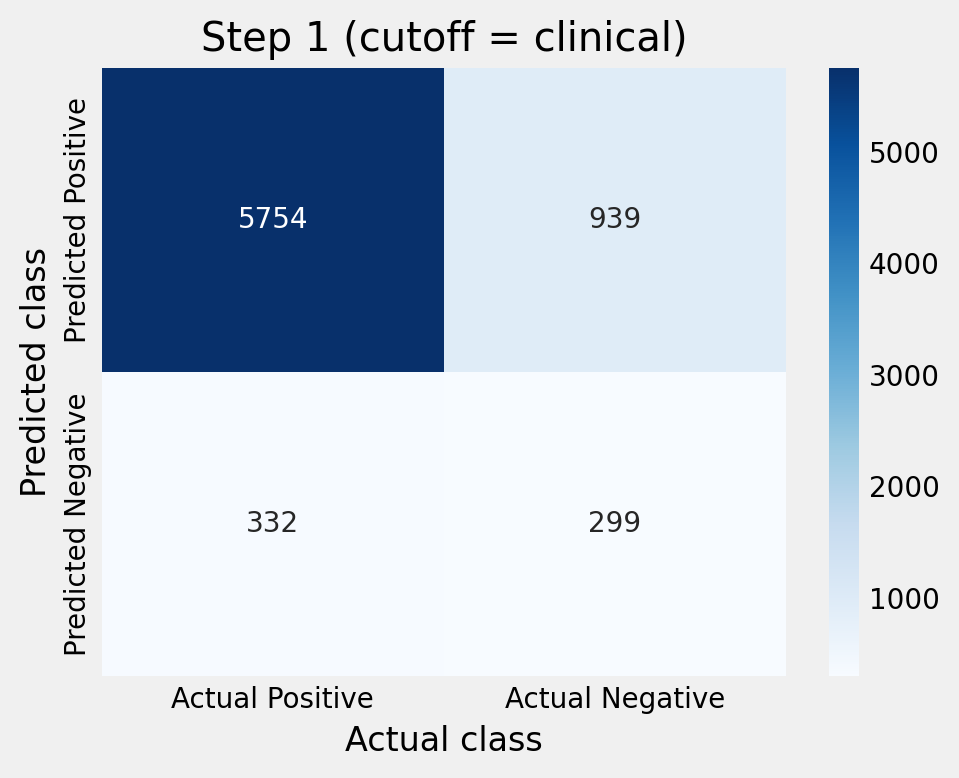

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Rows = Predicted | Columns = Actual
confusion_matrix_df = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predicted Positive", "Predicted Negative"],
    columns=["Actual Positive", "Actual Negative"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Step 1 (cutoff = clinical)")
plt.xlabel("Actual class")
plt.ylabel("Predicted class")

plt.tight_layout()

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/confusion_matrixt1_clin.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Calibracao

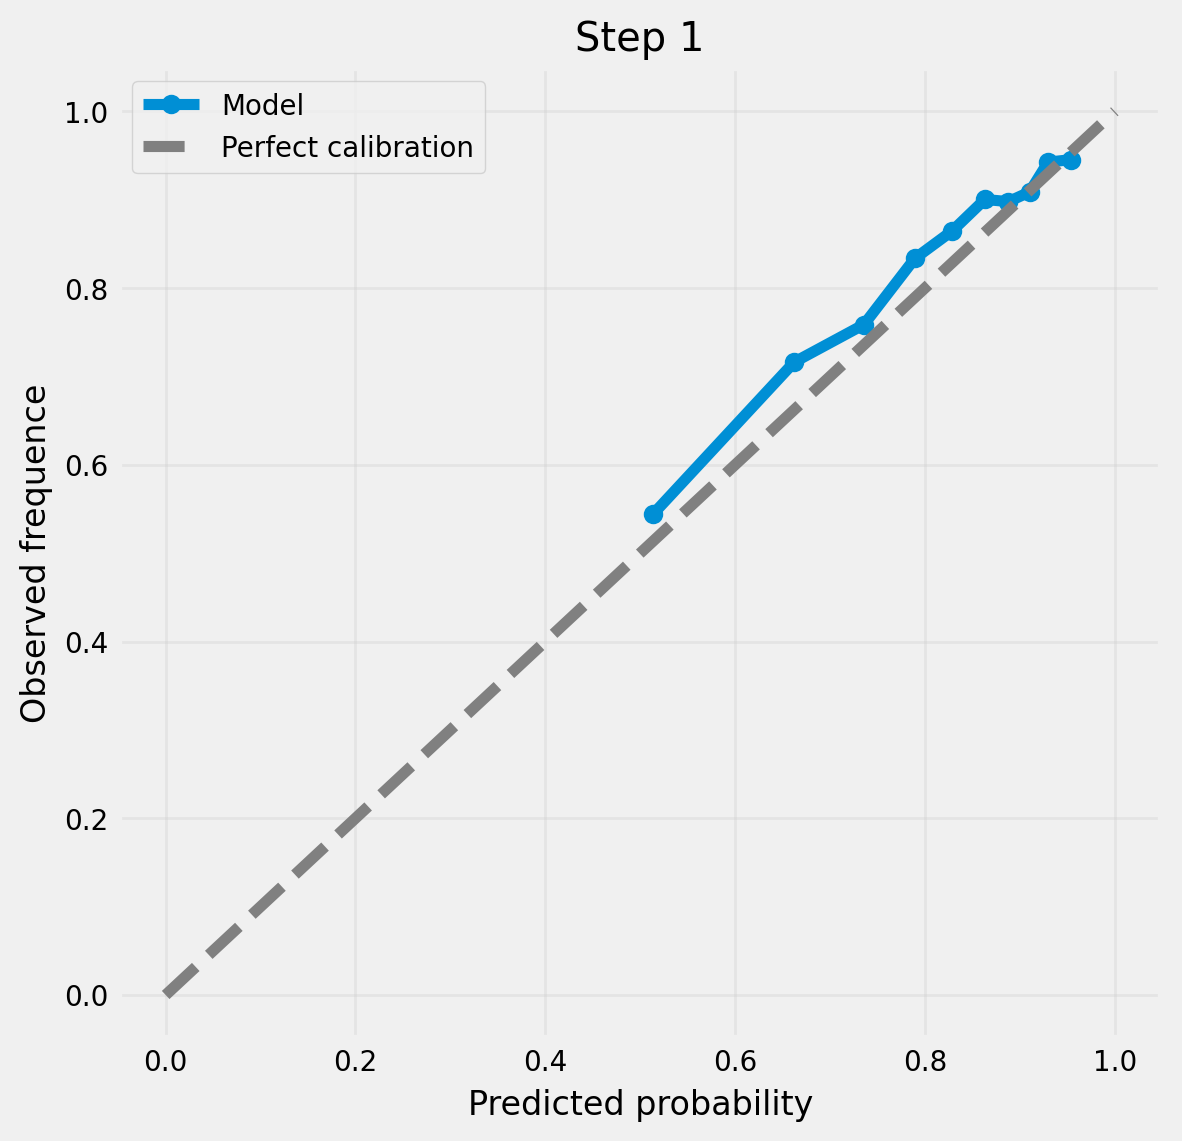

In [44]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, "o-", label="Model")
plt.plot([0,1], [0,1], "--", color="gray", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequence")
plt.title("Step 1")
plt.legend()
plt.grid(alpha=0.3)

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/calibration_plot1.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Brief score

In [45]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)

print(f"Brier score: {brier:.4f}")

Brier score: 0.1265


In [46]:
import numpy as np
import statsmodels.api as sm

# evita logit infinito
eps = 1e-15
p = np.clip(y_prob, eps, 1-eps)

logit_p = np.log(p/(1-p))

In [47]:
modelo_intercept = sm.GLM(
    y_test,
    np.ones(len(logit_p)),
    family=sm.families.Binomial(),
    offset=logit_p
).fit()

calibration_intercept = modelo_intercept.params[0]

print(f"Calibration intercept: {calibration_intercept:.4f}")

Calibration intercept: 0.1803


###Intercepto e slope

In [48]:
X = sm.add_constant(logit_p)

modelo = sm.GLM(
    y_test,
    X,
    family=sm.families.Binomial()
).fit()

calibration_intercept = modelo.params[0]
calibration_slope = modelo.params[1]

print(f"Calibration intercept: {calibration_intercept:.4f}")
print(f"Calibration slope    : {calibration_slope:.4f}")

Calibration intercept: 0.2225
Calibration slope    : 0.9651


In [49]:
print("==============================")
print("MODEL CALIBRATION")
print("==============================")

print(f"AUC                 : {auc:.4f}")
print(f"Brier score         : {brier:.4f}")
print(f"Calibration intercept: {calibration_intercept:.4f}")
print(f"Calibration slope    : {calibration_slope:.4f}")

MODEL CALIBRATION
AUC                 : 0.7225
Brier score         : 0.1265
Calibration intercept: 0.2225
Calibration slope    : 0.9651


In [50]:
from sklearn.metrics import brier_score_loss
from sklearn.utils import resample
import numpy as np
import statsmodels.api as sm

# =========================================================
# Métricas observadas
# =========================================================

# Brier score
brier = brier_score_loss(y_test, y_prob)

# Evita logit infinito
eps = 1e-15
p = np.clip(y_prob, eps, 1-eps)
logit_p = np.log(p/(1-p))

# Calibration intercept
modelo_intercept = sm.GLM(
    y_test,
    np.ones(len(logit_p)),
    family=sm.families.Binomial(),
    offset=logit_p
).fit()

calibration_intercept = modelo_intercept.params[0]

# Calibration intercept e slope
X = sm.add_constant(logit_p)

modelo = sm.GLM(
    y_test,
    X,
    family=sm.families.Binomial()
).fit()

calibration_intercept = modelo.params[0]
calibration_slope = modelo.params[1]

# =========================================================
# Bootstrap IC95%
# =========================================================

n_boot = 2000

brier_boot = []
intercept_boot = []
slope_boot = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_b = y_test_np[idx]
    p_b = y_prob_np[idx]

    if len(np.unique(y_b)) < 2:
        continue

    # ------------------------
    # Brier
    # ------------------------
    brier_boot.append(
        brier_score_loss(y_b, p_b)
    )

    # ------------------------
    # Logit
    # ------------------------
    p_b = np.clip(p_b, eps, 1-eps)
    logit_b = np.log(p_b/(1-p_b))

    try:

        # Calibration intercept
        modelo_i = sm.GLM(
            y_b,
            np.ones(len(logit_b)),
            family=sm.families.Binomial(),
            offset=logit_b
        ).fit(disp=0)

        intercept_boot.append(
            modelo_i.params[0]
        )

        # Calibration slope
        X_b = sm.add_constant(logit_b)

        modelo_s = sm.GLM(
            y_b,
            X_b,
            family=sm.families.Binomial()
        ).fit(disp=0)

        slope_boot.append(
            modelo_s.params[1]
        )

    except:
        continue

# =========================================================
# IC95%
# =========================================================

def ic95(x):
    return np.nanpercentile(x, [2.5,97.5])

brier_ic = ic95(brier_boot)
intercept_ic = ic95(intercept_boot)
slope_ic = ic95(slope_boot)

# =========================================================
# Resultados
# =========================================================

print("==============================")
print("MODEL CALIBRATION")
print("==============================")

print(f"AUC                   : {auc:.4f}")
print(f"Brier score           : {brier:.4f} ({brier_ic[0]:.4f} - {brier_ic[1]:.4f})")
print(f"Calibration intercept : {calibration_intercept:.4f} ({intercept_ic[0]:.4f} - {intercept_ic[1]:.4f})")
print(f"Calibration slope     : {calibration_slope:.4f} ({slope_ic[0]:.4f} - {slope_ic[1]:.4f})")

MODEL CALIBRATION
AUC                   : 0.7225
Brier score           : 0.1265 (0.1218 - 0.1312)
Calibration intercept : 0.2225 (0.1194 - 0.2443)
Calibration slope     : 0.9651 (0.8869 - 1.0481)


#Etapa2

In [51]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_cat2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_cat2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [52]:
df_train.shape

(17448, 24)

In [53]:
df_train.columns

Index(['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'cs_raca_2.0',
       'raiox_tora_4.0', 'agravalcoo_1.0', 'agravdiabe_1.0', 'cultura_es_2.0',
       'cultura_es_4.0', 'bacilosc_2_2.0', 'bacilosc_2_9.0', 'pop_liber_1.0',
       'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0',
       'agravtabac_1.0', 'escola_faixa_0.0', 'escola_faixa_1.0',
       'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0', 'cura'],
      dtype='object')

In [54]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

In [55]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.830754
0,0.169246


In [56]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat_novo.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [57]:
data = joblib.load(caminho)

cat = data["model_cat_novo"]
print(data["params_cat_novo"])
print(data["method_cat_novo"])

{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': 0.8680963214010124, 'reg_lambda': 1.7391886518816502}
Optuna


In [58]:
from catboost import CatBoostClassifier

# ===============================
# Criar DataFrame final de AUCs
# ===============================

params_cat = data["params_cat_novo"]

cat = CatBoostClassifier(
    **params_cat,
    **({"random_state": seed}
       if "random_state" not in params_cat
       else {})
)


In [59]:
X_train = df_train.drop(columns=['cura'])
y_train = df_train['cura']

cat.fit(X_train, y_train)

0:	learn: 0.6750315	total: 52.3ms	remaining: 26.1s
1:	learn: 0.6575900	total: 59.5ms	remaining: 14.8s
2:	learn: 0.6417231	total: 63.8ms	remaining: 10.6s
3:	learn: 0.6262777	total: 68.1ms	remaining: 8.44s
4:	learn: 0.6129074	total: 73.2ms	remaining: 7.24s
5:	learn: 0.5999679	total: 79.3ms	remaining: 6.53s
6:	learn: 0.5874922	total: 84.2ms	remaining: 5.93s
7:	learn: 0.5760238	total: 88.3ms	remaining: 5.43s
8:	learn: 0.5654338	total: 92.5ms	remaining: 5.04s
9:	learn: 0.5550258	total: 96.8ms	remaining: 4.74s
10:	learn: 0.5461178	total: 102ms	remaining: 4.54s
11:	learn: 0.5371500	total: 108ms	remaining: 4.39s
12:	learn: 0.5292608	total: 112ms	remaining: 4.21s
13:	learn: 0.5216348	total: 116ms	remaining: 4.04s
14:	learn: 0.5140779	total: 122ms	remaining: 3.94s
15:	learn: 0.5075998	total: 126ms	remaining: 3.81s
16:	learn: 0.5012291	total: 131ms	remaining: 3.71s
17:	learn: 0.4954245	total: 135ms	remaining: 3.61s
18:	learn: 0.4905174	total: 139ms	remaining: 3.53s
19:	learn: 0.4855838	total: 145

CatBoostClassifier(max_depth=4, min_data_in_leaf=5, n_estimators=500, random_state=42, reg_lambda=1.7391886518816502, subsample=0.8680963214010124)

In [60]:
print(X_train.shape)
print(y_train.shape)
print(y_train.value_counts(normalize=True))

(17448, 23)
(17448,)
cura
1    0.830754
0    0.169246
Name: proportion, dtype: float64


Criando cutoffs

In [61]:
cutoff_prev = y_train.mean()
print(cutoff_prev)

from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_train, cat.predict_proba(X_train_novo)[:,1])

youden = tpr - fpr

idx = np.argmax(youden)

cutoff_youden = thresholds[idx]

print(cutoff_youden)

from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(
    y_train,
    cat.predict_proba(X_train_novo)[:,1]
)

idx = np.where(tpr >= 0.95)[0][0]

cutoff_clinico = thresholds[idx]

print(cutoff_clinico)

0.8307542411737735
0.8225451189223223
0.6203539087242615


###Freq

In [62]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample

# --------------------------------------------------
# Probabilidades da classe positiva
# --------------------------------------------------
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# --------------------------------------------------
# AUC e ponto de corte
# --------------------------------------------------
auc = roc_auc_score(y_test, y_prob)

cutoff = cutoff_prev
y_pred = (y_prob >= cutoff).astype(int)

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# --------------------------------------------------
# Métricas
# --------------------------------------------------
sensibilidade = tp / (tp + fn)
especificidade = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

# --------------------------------------------------
# Bootstrap IC95%
# --------------------------------------------------
n_boot = 2000

aucs = []
sens = []
esp = []
vpps = []
vpns = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_true_b = y_test_np[idx]
    y_prob_b = y_prob_np[idx]

    # Necessário para cálculo da AUC
    if len(np.unique(y_true_b)) < 2:
        continue

    aucs.append(
        roc_auc_score(y_true_b, y_prob_b)
    )

    y_pred_b = (y_prob_b >= cutoff).astype(int)

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_true_b,
        y_pred_b,
        labels=[0, 1]
    ).ravel()

    sens.append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan)
    esp.append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan)
    vpps.append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan)
    vpns.append(tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan)


def ic95(x):
    return np.nanpercentile(x, [2.5, 97.5])

auc_ic = ic95(aucs)
sens_ic = ic95(sens)
esp_ic = ic95(esp)
vpp_ic = ic95(vpps)
vpn_ic = ic95(vpns)

print("\n==============================")
print("DESFECHO: CURA")
print("==============================")

print(f"AUC-ROC       : {auc:.4f} ({auc_ic[0]:.4f} - {auc_ic[1]:.4f})")
print(f"Sensibilidade : {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"Especificidade: {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"VPP           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")
print(f"VPN           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")

print("\n==============================")
print("DESFECHO: NÃO CURA")
print("==============================")

print(f"Sensibilidade : {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"Especificidade: {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"VPP           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")
print(f"VPN           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
print("\n==============================")
print("MATRIZ DE CONFUSÃO")
print("==============================")

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


DESFECHO: CURA
AUC-ROC       : 0.7619 (0.7456 - 0.7788)
Sensibilidade : 0.6946 (0.6829 - 0.7058)
Especificidade: 0.6991 (0.6712 - 0.7270)
VPP           : 0.9302 (0.9227 - 0.9377)
VPN           : 0.2841 (0.2669 - 0.3020)

DESFECHO: NÃO CURA
Sensibilidade : 0.6991 (0.6712 - 0.7270)
Especificidade: 0.6946 (0.6829 - 0.7058)
VPP           : 0.2841 (0.2669 - 0.3020)
VPN           : 0.9302 (0.9227 - 0.9377)

MATRIZ DE CONFUSÃO
TN = 732
FP = 315
FN = 1845
TP = 4197


In [63]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

# Probabilidades da classe positiva
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Ponto de corte
cutoff = cutoff_prev

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Métricas
sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Preditivo Positivo
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Preditivo Negativo

# Resultados
print(f"AUC-ROC       : {auc:.4f}")
print(f"Sensibilidade : {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"VPP           : {vpp:.4f}")
print(f"VPN           : {vpn:.4f}")

print("\nMatriz de Confusão")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

AUC-ROC       : 0.7619
Sensibilidade : 0.6946
Especificidade: 0.6991
VPP           : 0.9302
VPN           : 0.2841

Matriz de Confusão
TN = 732
FP = 315
FN = 1845
TP = 4197


In [64]:
from sklearn.metrics import confusion_matrix

# Probabilidades
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# Ponto de corte
cutoff = cutoff_prev

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 732  315]
 [1845 4197]]


In [65]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Linhas = Predito | Colunas = Real
matriz_invertida = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predito 1", "Predito 0"],
    columns=["Real 1", "Real 0"]
)

print(matriz_invertida)

           Real 1  Real 0
Predito 1    4197     315
Predito 0    1845     732


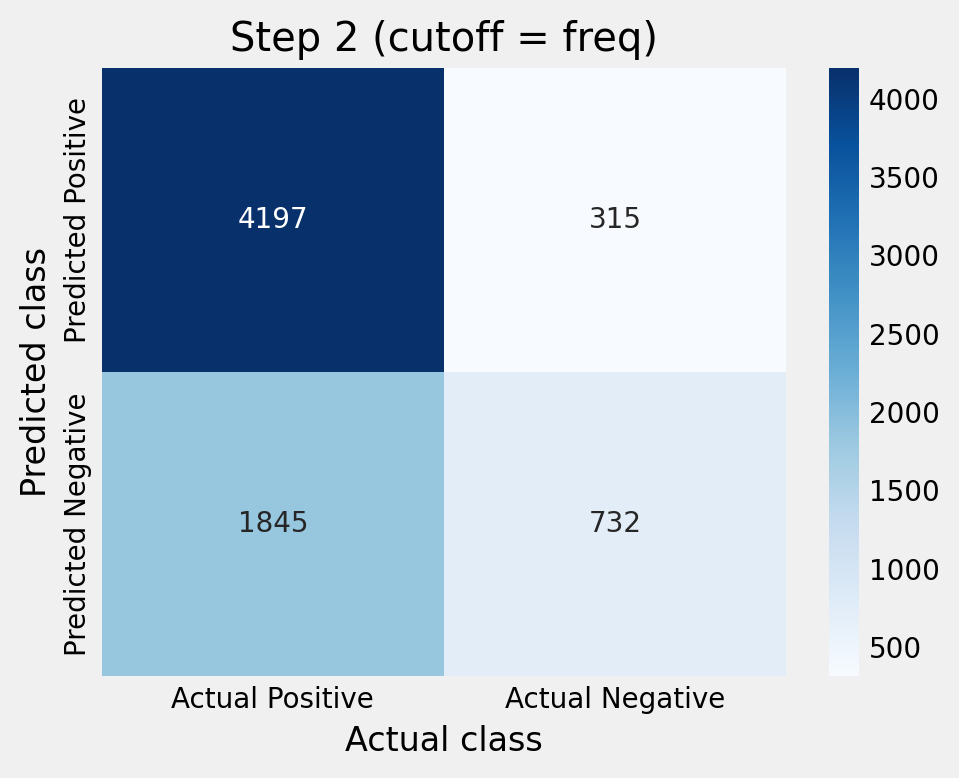

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Rows = Predicted | Columns = Actual
confusion_matrix_df = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predicted Positive", "Predicted Negative"],
    columns=["Actual Positive", "Actual Negative"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Step 2 (cutoff = freq)")
plt.xlabel("Actual class")
plt.ylabel("Predicted class")

plt.tight_layout()

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/confusion_matrixt2_freq.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Youden

In [67]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample

# --------------------------------------------------
# Probabilidades da classe positiva
# --------------------------------------------------
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# --------------------------------------------------
# AUC e ponto de corte
# --------------------------------------------------
auc = roc_auc_score(y_test, y_prob)

cutoff = cutoff_youden
y_pred = (y_prob >= cutoff).astype(int)

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# --------------------------------------------------
# Métricas
# --------------------------------------------------
sensibilidade = tp / (tp + fn)
especificidade = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

# --------------------------------------------------
# Bootstrap IC95%
# --------------------------------------------------
n_boot = 2000

aucs = []
sens = []
esp = []
vpps = []
vpns = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_true_b = y_test_np[idx]
    y_prob_b = y_prob_np[idx]

    # Necessário para cálculo da AUC
    if len(np.unique(y_true_b)) < 2:
        continue

    aucs.append(
        roc_auc_score(y_true_b, y_prob_b)
    )

    y_pred_b = (y_prob_b >= cutoff).astype(int)

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_true_b,
        y_pred_b,
        labels=[0, 1]
    ).ravel()

    sens.append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan)
    esp.append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan)
    vpps.append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan)
    vpns.append(tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan)


def ic95(x):
    return np.nanpercentile(x, [2.5, 97.5])

auc_ic = ic95(aucs)
sens_ic = ic95(sens)
esp_ic = ic95(esp)
vpp_ic = ic95(vpps)
vpn_ic = ic95(vpns)

print("\n==============================")
print("DESFECHO: CURA")
print("==============================")

print(f"AUC-ROC       : {auc:.4f} ({auc_ic[0]:.4f} - {auc_ic[1]:.4f})")
print(f"Sensibilidade : {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"Especificidade: {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"VPP           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")
print(f"VPN           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")

print("\n==============================")
print("DESFECHO: NÃO CURA")
print("==============================")

print(f"Sensibilidade : {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"Especificidade: {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"VPP           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")
print(f"VPN           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
print("\n==============================")
print("MATRIZ DE CONFUSÃO")
print("==============================")

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


DESFECHO: CURA
AUC-ROC       : 0.7619 (0.7452 - 0.7768)
Sensibilidade : 0.7152 (0.7038 - 0.7262)
Especificidade: 0.6858 (0.6565 - 0.7131)
VPP           : 0.9292 (0.9219 - 0.9362)
VPN           : 0.2944 (0.2765 - 0.3116)

DESFECHO: NÃO CURA
Sensibilidade : 0.6858 (0.6565 - 0.7131)
Especificidade: 0.7152 (0.7038 - 0.7262)
VPP           : 0.2944 (0.2765 - 0.3116)
VPN           : 0.9292 (0.9219 - 0.9362)

MATRIZ DE CONFUSÃO
TN = 718
FP = 329
FN = 1721
TP = 4321


In [68]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

# Probabilidades da classe positiva
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Ponto de corte
cutoff = cutoff_youden

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Métricas
sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Preditivo Positivo
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Preditivo Negativo

# Resultados
print(f"AUC-ROC       : {auc:.4f}")
print(f"Sensibilidade : {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"VPP           : {vpp:.4f}")
print(f"VPN           : {vpn:.4f}")

print("\nMatriz de Confusão")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

AUC-ROC       : 0.7619
Sensibilidade : 0.7152
Especificidade: 0.6858
VPP           : 0.9292
VPN           : 0.2944

Matriz de Confusão
TN = 718
FP = 329
FN = 1721
TP = 4321


In [69]:
from sklearn.metrics import confusion_matrix

# Probabilidades
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# Ponto de corte
cutoff = cutoff_youden

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 718  329]
 [1721 4321]]


In [70]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Linhas = Predito | Colunas = Real
matriz_invertida = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predito 1", "Predito 0"],
    columns=["Real 1", "Real 0"]
)

print(matriz_invertida)

           Real 1  Real 0
Predito 1    4321     329
Predito 0    1721     718


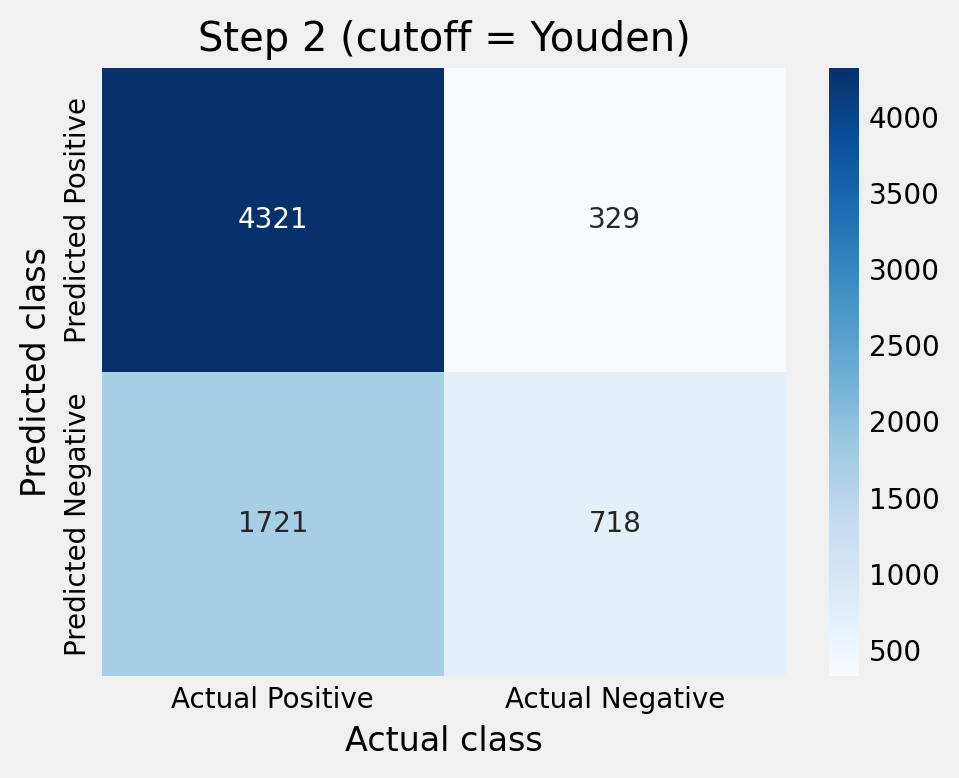

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Rows = Predicted | Columns = Actual
confusion_matrix_df = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predicted Positive", "Predicted Negative"],
    columns=["Actual Positive", "Actual Negative"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Step 2 (cutoff = Youden)")
plt.xlabel("Actual class")
plt.ylabel("Predicted class")

plt.tight_layout()

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/confusion_matrixt2_youden.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Calibracao

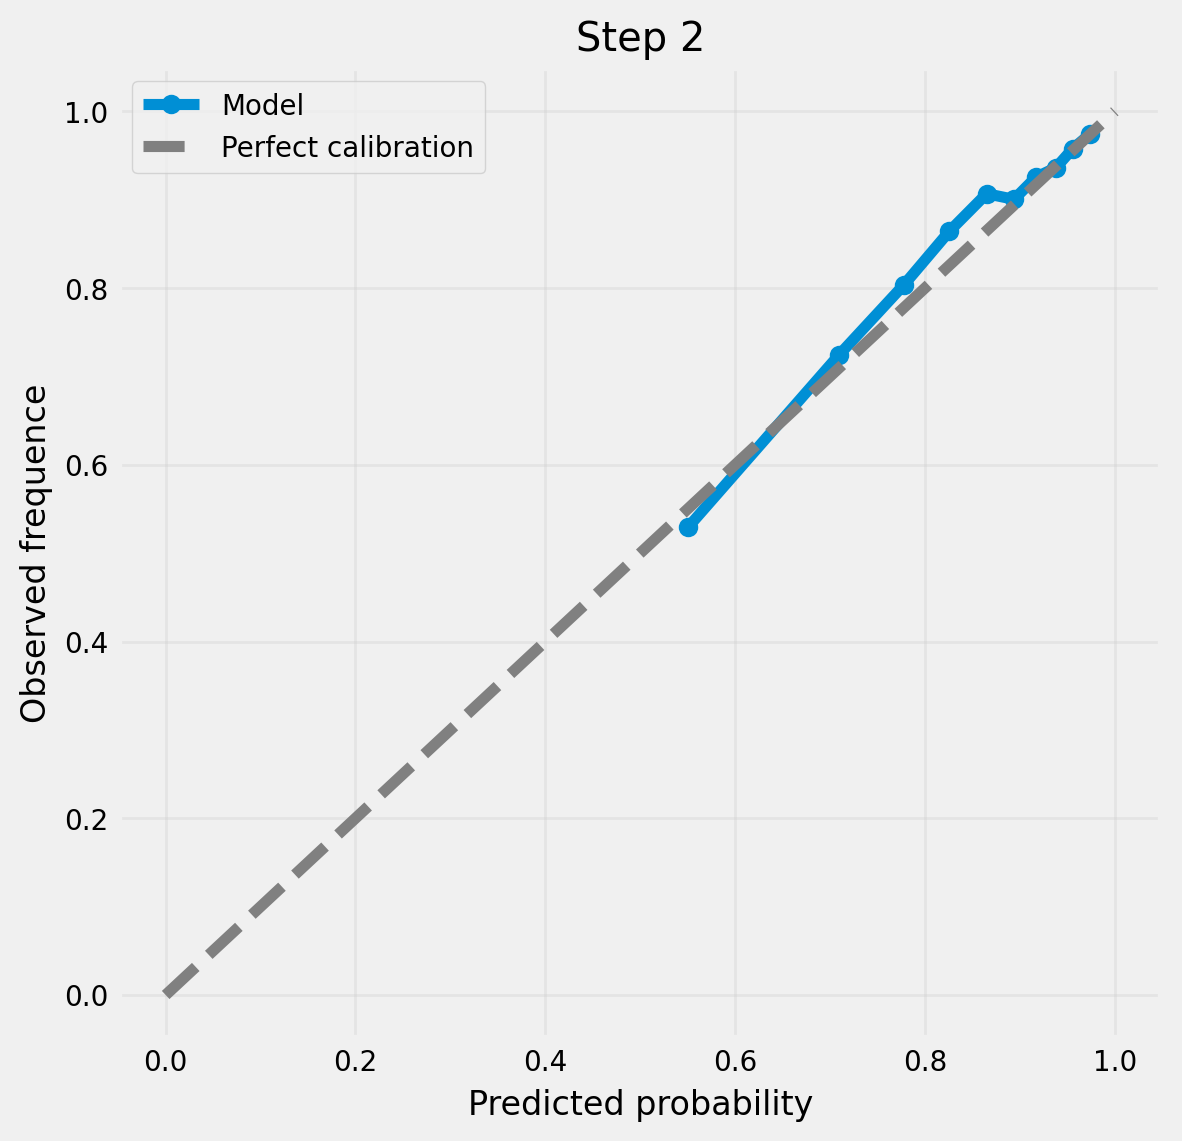

In [72]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, "o-", label="Model")
plt.plot([0,1], [0,1], "--", color="gray", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequence")
plt.title("Step 2")
plt.legend()
plt.grid(alpha=0.3)

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/calibration_plot2.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Brief score

In [73]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)

print(f"Brier score: {brier:.4f}")

Brier score: 0.1087


In [74]:
import numpy as np
import statsmodels.api as sm

# evita logit infinito
eps = 1e-15
p = np.clip(y_prob, eps, 1-eps)

logit_p = np.log(p/(1-p))

In [75]:
modelo_intercept = sm.GLM(
    y_test,
    np.ones(len(logit_p)),
    family=sm.families.Binomial(),
    offset=logit_p
).fit()

calibration_intercept = modelo_intercept.params[0]

print(f"Calibration intercept: {calibration_intercept:.4f}")

Calibration intercept: 0.1014


###Intercepto e slope

In [76]:
X = sm.add_constant(logit_p)

modelo = sm.GLM(
    y_test,
    X,
    family=sm.families.Binomial()
).fit()

calibration_intercept = modelo.params[0]
calibration_slope = modelo.params[1]

print(f"Calibration intercept: {calibration_intercept:.4f}")
print(f"Calibration slope    : {calibration_slope:.4f}")

Calibration intercept: 0.0162
Calibration slope    : 1.0622


In [77]:
print("==============================")
print("MODEL CALIBRATION")
print("==============================")

print(f"AUC                 : {auc:.4f}")
print(f"Brier score         : {brier:.4f}")
print(f"Calibration intercept: {calibration_intercept:.4f}")
print(f"Calibration slope    : {calibration_slope:.4f}")

MODEL CALIBRATION
AUC                 : 0.7619
Brier score         : 0.1087
Calibration intercept: 0.0162
Calibration slope    : 1.0622


In [78]:
from sklearn.metrics import brier_score_loss
from sklearn.utils import resample
import numpy as np
import statsmodels.api as sm

# =========================================================
# Métricas observadas
# =========================================================

# Brier score
brier = brier_score_loss(y_test, y_prob)

# Evita logit infinito
eps = 1e-15
p = np.clip(y_prob, eps, 1-eps)
logit_p = np.log(p/(1-p))

# Calibration intercept
modelo_intercept = sm.GLM(
    y_test,
    np.ones(len(logit_p)),
    family=sm.families.Binomial(),
    offset=logit_p
).fit()

calibration_intercept = modelo_intercept.params[0]

# Calibration intercept e slope
X = sm.add_constant(logit_p)

modelo = sm.GLM(
    y_test,
    X,
    family=sm.families.Binomial()
).fit()

calibration_intercept = modelo.params[0]
calibration_slope = modelo.params[1]

# =========================================================
# Bootstrap IC95%
# =========================================================

n_boot = 2000

brier_boot = []
intercept_boot = []
slope_boot = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_b = y_test_np[idx]
    p_b = y_prob_np[idx]

    if len(np.unique(y_b)) < 2:
        continue

    # ------------------------
    # Brier
    # ------------------------
    brier_boot.append(
        brier_score_loss(y_b, p_b)
    )

    # ------------------------
    # Logit
    # ------------------------
    p_b = np.clip(p_b, eps, 1-eps)
    logit_b = np.log(p_b/(1-p_b))

    try:

        # Calibration intercept
        modelo_i = sm.GLM(
            y_b,
            np.ones(len(logit_b)),
            family=sm.families.Binomial(),
            offset=logit_b
        ).fit(disp=0)

        intercept_boot.append(
            modelo_i.params[0]
        )

        # Calibration slope
        X_b = sm.add_constant(logit_b)

        modelo_s = sm.GLM(
            y_b,
            X_b,
            family=sm.families.Binomial()
        ).fit(disp=0)

        slope_boot.append(
            modelo_s.params[1]
        )

    except:
        continue

# =========================================================
# IC95%
# =========================================================

def ic95(x):
    return np.nanpercentile(x, [2.5,97.5])

brier_ic = ic95(brier_boot)
intercept_ic = ic95(intercept_boot)
slope_ic = ic95(slope_boot)

# =========================================================
# Resultados
# =========================================================

print("==============================")
print("MODEL CALIBRATION")
print("==============================")

print(f"AUC                   : {auc:.4f}")
print(f"Brier score           : {brier:.4f} ({brier_ic[0]:.4f} - {brier_ic[1]:.4f})")
print(f"Calibration intercept : {calibration_intercept:.4f} ({intercept_ic[0]:.4f} - {intercept_ic[1]:.4f})")
print(f"Calibration slope     : {calibration_slope:.4f} ({slope_ic[0]:.4f} - {slope_ic[1]:.4f})")

MODEL CALIBRATION
AUC                   : 0.7619
Brier score           : 0.1087 (0.1039 - 0.1135)
Calibration intercept : 0.0162 (0.0364 - 0.1699)
Calibration slope     : 1.0622 (0.9813 - 1.1450)


#Etapa3

In [79]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_cat3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_cat3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [80]:
df_train.shape

(16389, 20)

In [81]:
df_train.columns

Index(['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'agravdiabe_1.0',
       'bacilosc_e_2.0', 'cultura_es_2.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0',
       'bacilosc_4_2.0', 'bacilosc_4_9.0', 'pop_rua_1.0', 'agravdroga_0.0',
       'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0',
       'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_3.0', 'cura'],
      dtype='object')

In [82]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

In [83]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.878089
0,0.121911


##Catboost

In [84]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat_novo.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [85]:
data = joblib.load(caminho)

cat = data["model_cat_novo"]
print(data["params_cat_novo"])
print(data["method_cat_novo"])

{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.9933475821943013, 'reg_lambda': 1.3719132702327823}
Optuna


In [86]:
from catboost import CatBoostClassifier

# ===============================
# Criar DataFrame final de AUCs
# ===============================

params_cat = data["params_cat_novo"]

cat = CatBoostClassifier(
    **params_cat,
    **({"random_state": seed}
       if "random_state" not in params_cat
       else {})
)


In [87]:
X_train = df_train.drop(columns=['cura'])
y_train = df_train['cura']

cat.fit(X_train, y_train)

0:	learn: 0.6702036	total: 5.38ms	remaining: 2.69s
1:	learn: 0.6469560	total: 11.3ms	remaining: 2.8s
2:	learn: 0.6256999	total: 16.8ms	remaining: 2.79s
3:	learn: 0.6053795	total: 23.1ms	remaining: 2.86s
4:	learn: 0.5862725	total: 28.6ms	remaining: 2.83s
5:	learn: 0.5706788	total: 34.6ms	remaining: 2.85s
6:	learn: 0.5543936	total: 40.2ms	remaining: 2.83s
7:	learn: 0.5389981	total: 46.3ms	remaining: 2.85s
8:	learn: 0.5256233	total: 52.2ms	remaining: 2.85s
9:	learn: 0.5128075	total: 58.1ms	remaining: 2.84s
10:	learn: 0.5008946	total: 63.9ms	remaining: 2.84s
11:	learn: 0.4895058	total: 69.4ms	remaining: 2.82s
12:	learn: 0.4802743	total: 74.8ms	remaining: 2.8s
13:	learn: 0.4702742	total: 81.4ms	remaining: 2.83s
14:	learn: 0.4613896	total: 90.3ms	remaining: 2.92s
15:	learn: 0.4536479	total: 98.2ms	remaining: 2.97s
16:	learn: 0.4465703	total: 105ms	remaining: 2.99s
17:	learn: 0.4391857	total: 112ms	remaining: 3s
18:	learn: 0.4331686	total: 122ms	remaining: 3.09s
19:	learn: 0.4268579	total: 13

CatBoostClassifier(max_depth=3, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=1.3719132702327823, subsample=0.9933475821943013)

In [88]:
print(X_train.shape)
print(y_train.shape)
print(y_train.value_counts(normalize=True))

(16389, 19)
(16389,)
cura
1    0.878089
0    0.121911
Name: proportion, dtype: float64


In [89]:
cutoff_prev = y_train.mean()
print(cutoff_prev)

from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_train, cat.predict_proba(X_train_novo)[:,1])

youden = tpr - fpr

idx = np.argmax(youden)

cutoff_youden = thresholds[idx]

print(cutoff_youden)

from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(
    y_train,
    cat.predict_proba(X_train_novo)[:,1]
)

idx = np.where(tpr >= 0.95)[0][0]

cutoff_clinico = thresholds[idx]

print(cutoff_clinico)

0.8780889621087314
0.8788232493249234
0.6988261392649839


###Freq

In [90]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample

# --------------------------------------------------
# Probabilidades da classe positiva
# --------------------------------------------------
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# --------------------------------------------------
# AUC e ponto de corte
# --------------------------------------------------
auc = roc_auc_score(y_test, y_prob)

cutoff = cutoff_prev
y_pred = (y_prob >= cutoff).astype(int)

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# --------------------------------------------------
# Métricas
# --------------------------------------------------
sensibilidade = tp / (tp + fn)
especificidade = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

# --------------------------------------------------
# Bootstrap IC95%
# --------------------------------------------------
n_boot = 2000

aucs = []
sens = []
esp = []
vpps = []
vpns = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_true_b = y_test_np[idx]
    y_prob_b = y_prob_np[idx]

    # Necessário para cálculo da AUC
    if len(np.unique(y_true_b)) < 2:
        continue

    aucs.append(
        roc_auc_score(y_true_b, y_prob_b)
    )

    y_pred_b = (y_prob_b >= cutoff).astype(int)

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_true_b,
        y_pred_b,
        labels=[0, 1]
    ).ravel()

    sens.append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan)
    esp.append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan)
    vpps.append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan)
    vpns.append(tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan)


def ic95(x):
    return np.nanpercentile(x, [2.5, 97.5])

auc_ic = ic95(aucs)
sens_ic = ic95(sens)
esp_ic = ic95(esp)
vpp_ic = ic95(vpps)
vpn_ic = ic95(vpns)

print("\n==============================")
print("DESFECHO: CURA")
print("==============================")

print(f"AUC-ROC       : {auc:.4f} ({auc_ic[0]:.4f} - {auc_ic[1]:.4f})")
print(f"Sensibilidade : {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"Especificidade: {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"VPP           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")
print(f"VPN           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")

print("\n==============================")
print("DESFECHO: NÃO CURA")
print("==============================")

print(f"Sensibilidade : {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"Especificidade: {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"VPP           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")
print(f"VPN           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
print("\n==============================")
print("MATRIZ DE CONFUSÃO")
print("==============================")

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


DESFECHO: CURA
AUC-ROC       : 0.7669 (0.7481 - 0.7862)
Sensibilidade : 0.7164 (0.7054 - 0.7276)
Especificidade: 0.6964 (0.6608 - 0.7313)
VPP           : 0.9511 (0.9448 - 0.9575)
VPN           : 0.2294 (0.2119 - 0.2465)

DESFECHO: NÃO CURA
Sensibilidade : 0.6964 (0.6608 - 0.7313)
Especificidade: 0.7164 (0.7054 - 0.7276)
VPP           : 0.2294 (0.2119 - 0.2465)
VPN           : 0.9511 (0.9448 - 0.9575)

MATRIZ DE CONFUSÃO
TN = 507
FP = 221
FN = 1703
TP = 4301


In [91]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

# Probabilidades da classe positiva
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Ponto de corte
cutoff = cutoff_prev

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Métricas
sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Preditivo Positivo
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Preditivo Negativo

# Resultados
print(f"AUC-ROC       : {auc:.4f}")
print(f"Sensibilidade : {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"VPP           : {vpp:.4f}")
print(f"VPN           : {vpn:.4f}")

print("\nMatriz de Confusão")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

AUC-ROC       : 0.7669
Sensibilidade : 0.7164
Especificidade: 0.6964
VPP           : 0.9511
VPN           : 0.2294

Matriz de Confusão
TN = 507
FP = 221
FN = 1703
TP = 4301


In [92]:
from sklearn.metrics import confusion_matrix

# Probabilidades
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# Ponto de corte
cutoff = cutoff_prev

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 507  221]
 [1703 4301]]


In [93]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Linhas = Predito | Colunas = Real
matriz_invertida = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predito 1", "Predito 0"],
    columns=["Real 1", "Real 0"]
)

print(matriz_invertida)

           Real 1  Real 0
Predito 1    4301     221
Predito 0    1703     507


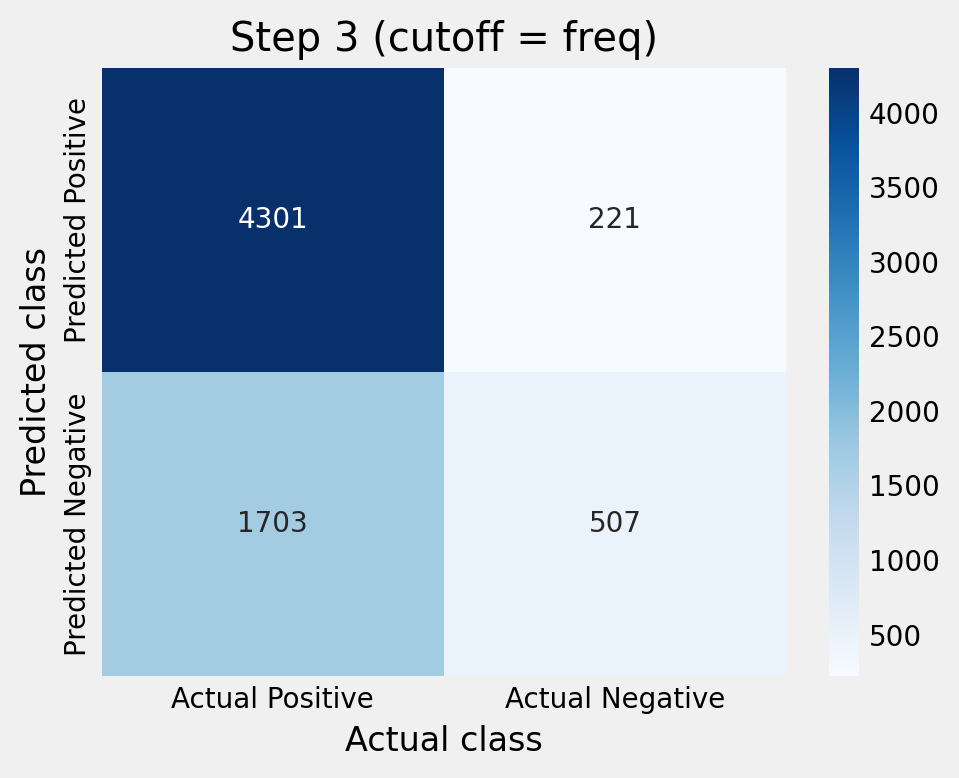

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Rows = Predicted | Columns = Actual
confusion_matrix_df = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predicted Positive", "Predicted Negative"],
    columns=["Actual Positive", "Actual Negative"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Step 3 (cutoff = freq)")
plt.xlabel("Actual class")
plt.ylabel("Predicted class")

plt.tight_layout()

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/confusion_matrixt3_freq.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Youden

In [95]:
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample

# --------------------------------------------------
# Probabilidades da classe positiva
# --------------------------------------------------
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# --------------------------------------------------
# AUC e ponto de corte
# --------------------------------------------------
auc = roc_auc_score(y_test, y_prob)

cutoff = cutoff_youden
y_pred = (y_prob >= cutoff).astype(int)

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# --------------------------------------------------
# Métricas
# --------------------------------------------------
sensibilidade = tp / (tp + fn)
especificidade = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

# --------------------------------------------------
# Bootstrap IC95%
# --------------------------------------------------
n_boot = 2000

aucs = []
sens = []
esp = []
vpps = []
vpns = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_true_b = y_test_np[idx]
    y_prob_b = y_prob_np[idx]

    # Necessário para cálculo da AUC
    if len(np.unique(y_true_b)) < 2:
        continue

    aucs.append(
        roc_auc_score(y_true_b, y_prob_b)
    )

    y_pred_b = (y_prob_b >= cutoff).astype(int)

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_true_b,
        y_pred_b,
        labels=[0, 1]
    ).ravel()

    sens.append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan)
    esp.append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan)
    vpps.append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan)
    vpns.append(tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan)


def ic95(x):
    return np.nanpercentile(x, [2.5, 97.5])

auc_ic = ic95(aucs)
sens_ic = ic95(sens)
esp_ic = ic95(esp)
vpp_ic = ic95(vpps)
vpn_ic = ic95(vpns)

print("\n==============================")
print("DESFECHO: CURA")
print("==============================")

print(f"AUC-ROC       : {auc:.4f} ({auc_ic[0]:.4f} - {auc_ic[1]:.4f})")
print(f"Sensibilidade : {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"Especificidade: {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"VPP           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")
print(f"VPN           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")

print("\n==============================")
print("DESFECHO: NÃO CURA")
print("==============================")

print(f"Sensibilidade : {especificidade:.4f} ({esp_ic[0]:.4f} - {esp_ic[1]:.4f})")
print(f"Especificidade: {sensibilidade:.4f} ({sens_ic[0]:.4f} - {sens_ic[1]:.4f})")
print(f"VPP           : {vpn:.4f} ({vpn_ic[0]:.4f} - {vpn_ic[1]:.4f})")
print(f"VPN           : {vpp:.4f} ({vpp_ic[0]:.4f} - {vpp_ic[1]:.4f})")

# --------------------------------------------------
# Matriz de confusão
# --------------------------------------------------
print("\n==============================")
print("MATRIZ DE CONFUSÃO")
print("==============================")

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


DESFECHO: CURA
AUC-ROC       : 0.7669 (0.7481 - 0.7846)
Sensibilidade : 0.7140 (0.7029 - 0.7256)
Especificidade: 0.6964 (0.6640 - 0.7304)
VPP           : 0.9510 (0.9450 - 0.9574)
VPN           : 0.2280 (0.2106 - 0.2472)

DESFECHO: NÃO CURA
Sensibilidade : 0.6964 (0.6640 - 0.7304)
Especificidade: 0.7140 (0.7029 - 0.7256)
VPP           : 0.2280 (0.2106 - 0.2472)
VPN           : 0.9510 (0.9450 - 0.9574)

MATRIZ DE CONFUSÃO
TN = 507
FP = 221
FN = 1717
TP = 4287


In [96]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix
)

# Probabilidades da classe positiva
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# AUC-ROC
auc = roc_auc_score(y_test, y_prob)

# Ponto de corte
cutoff = cutoff_youden

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Métricas
sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0  # Valor Preditivo Positivo
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor Preditivo Negativo

# Resultados
print(f"AUC-ROC       : {auc:.4f}")
print(f"Sensibilidade : {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"VPP           : {vpp:.4f}")
print(f"VPN           : {vpn:.4f}")

print("\nMatriz de Confusão")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

AUC-ROC       : 0.7669
Sensibilidade : 0.7140
Especificidade: 0.6964
VPP           : 0.9510
VPN           : 0.2280

Matriz de Confusão
TN = 507
FP = 221
FN = 1717
TP = 4287


In [97]:
from sklearn.metrics import confusion_matrix

# Probabilidades
y_prob = cat.predict_proba(X_test_novo)[:, 1]

# Ponto de corte
cutoff = cutoff_youden

# Classes preditas
y_pred = (y_prob >= cutoff).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 507  221]
 [1717 4287]]


In [98]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Linhas = Predito | Colunas = Real
matriz_invertida = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predito 1", "Predito 0"],
    columns=["Real 1", "Real 0"]
)

print(matriz_invertida)

           Real 1  Real 0
Predito 1    4287     221
Predito 0    1717     507


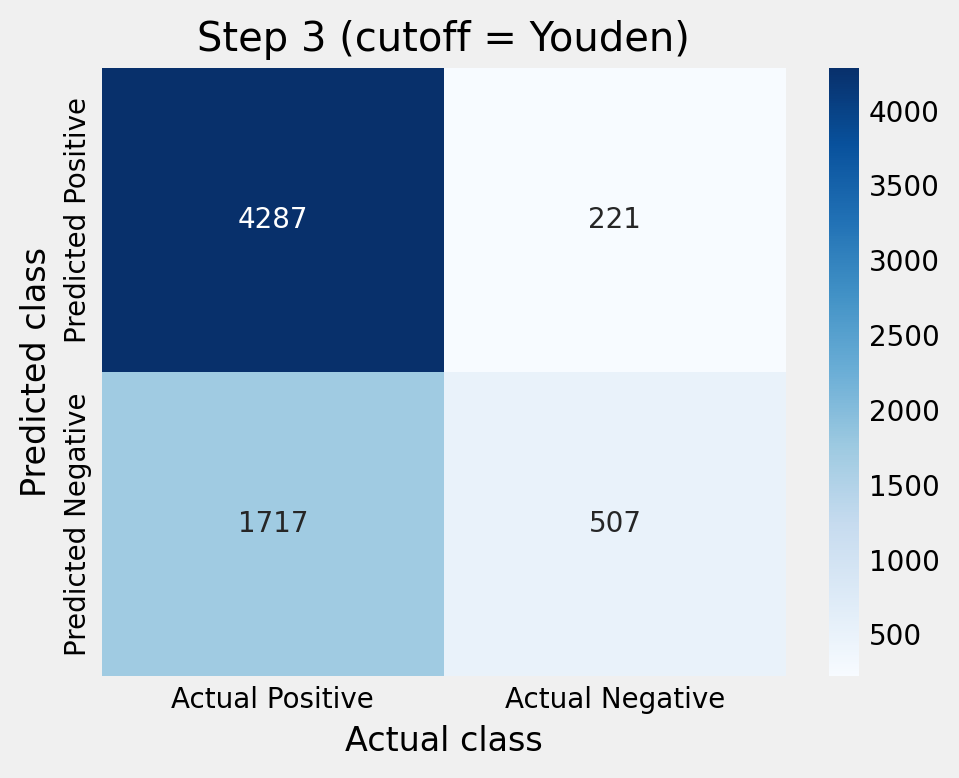

In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Rows = Predicted | Columns = Actual
confusion_matrix_df = pd.DataFrame(
    [[tp, fp],
     [fn, tn]],
    index=["Predicted Positive", "Predicted Negative"],
    columns=["Actual Positive", "Actual Negative"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Step 3 (cutoff = Youden)")
plt.xlabel("Actual class")
plt.ylabel("Predicted class")

plt.tight_layout()

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/confusion_matrixt3_youden.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Calibracao

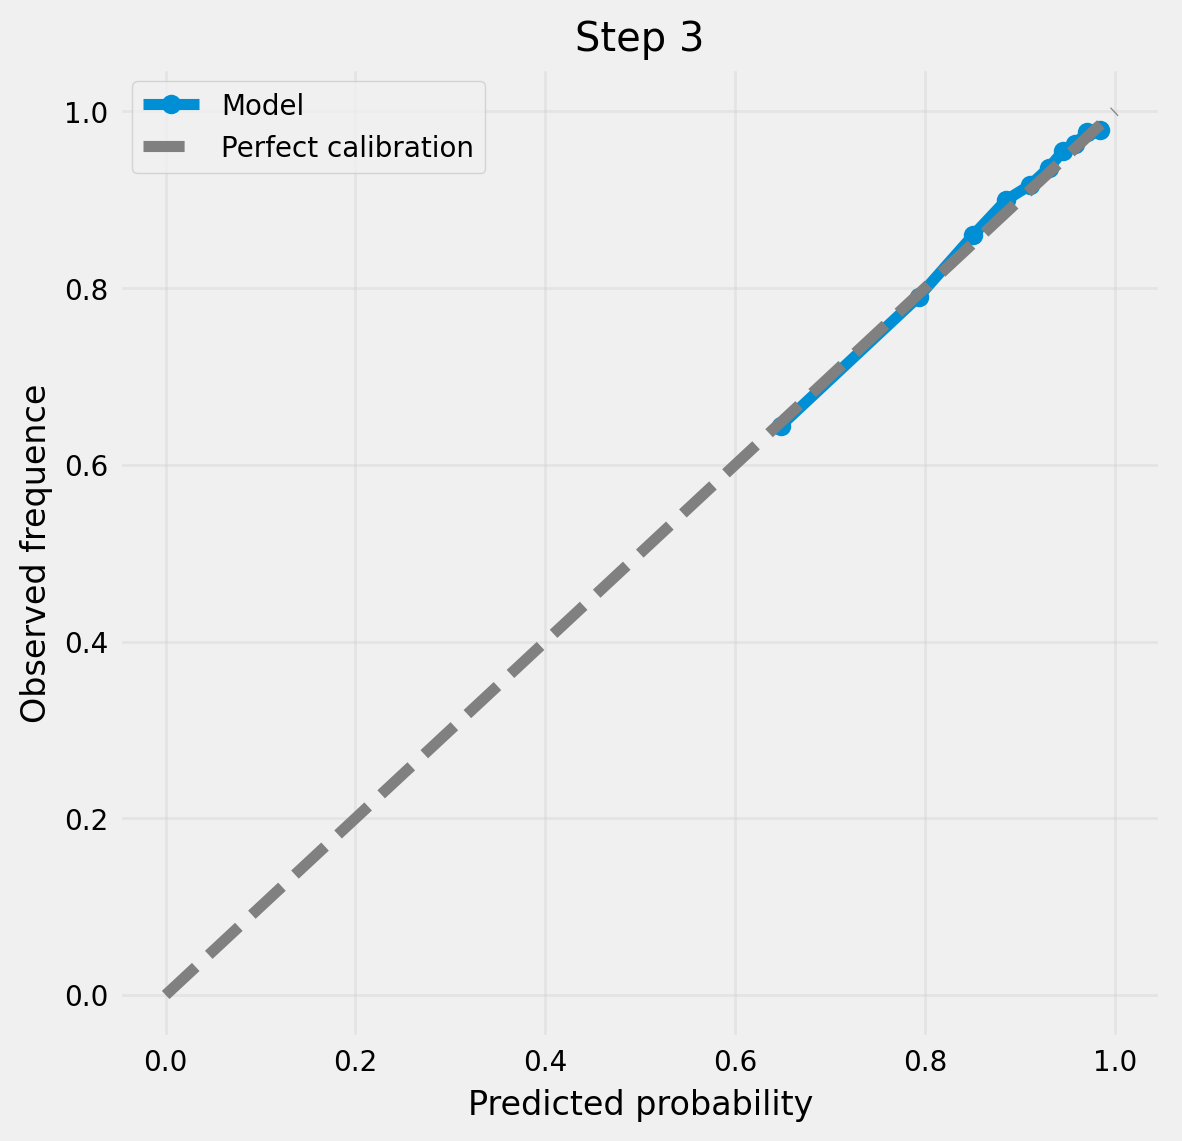

In [100]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, "o-", label="Model")
plt.plot([0,1], [0,1], "--", color="gray", label="Perfect calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequence")
plt.title("Step 3")
plt.legend()
plt.grid(alpha=0.3)

# Salvar em TIFF (300 dpi)

plt.savefig(
    "/content/calibration_plot3.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###Brief score

In [101]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)

print(f"Brier score: {brier:.4f}")

Brier score: 0.0852


In [102]:
import numpy as np
import statsmodels.api as sm

# evita logit infinito
eps = 1e-15
p = np.clip(y_prob, eps, 1-eps)

logit_p = np.log(p/(1-p))

In [103]:
modelo_intercept = sm.GLM(
    y_test,
    np.ones(len(logit_p)),
    family=sm.families.Binomial(),
    offset=logit_p
).fit()

calibration_intercept = modelo_intercept.params[0]

print(f"Calibration intercept: {calibration_intercept:.4f}")

Calibration intercept: 0.0477


In [104]:
X = sm.add_constant(logit_p)

modelo = sm.GLM(
    y_test,
    X,
    family=sm.families.Binomial()
).fit()

calibration_intercept = modelo.params[0]
calibration_slope = modelo.params[1]

print(f"Calibration intercept: {calibration_intercept:.4f}")
print(f"Calibration slope    : {calibration_slope:.4f}")

Calibration intercept: -0.0319
Calibration slope    : 1.0456


In [105]:
print("==============================")
print("MODEL CALIBRATION")
print("==============================")

print(f"AUC                 : {auc:.4f}")
print(f"Brier score         : {brier:.4f}")
print(f"Calibration intercept: {calibration_intercept:.4f}")
print(f"Calibration slope    : {calibration_slope:.4f}")

MODEL CALIBRATION
AUC                 : 0.7669
Brier score         : 0.0852
Calibration intercept: -0.0319
Calibration slope    : 1.0456


In [106]:
from sklearn.metrics import brier_score_loss
from sklearn.utils import resample
import numpy as np
import statsmodels.api as sm

# =========================================================
# Métricas observadas
# =========================================================

# Brier score
brier = brier_score_loss(y_test, y_prob)

# Evita logit infinito
eps = 1e-15
p = np.clip(y_prob, eps, 1-eps)
logit_p = np.log(p/(1-p))

# Calibration intercept
modelo_intercept = sm.GLM(
    y_test,
    np.ones(len(logit_p)),
    family=sm.families.Binomial(),
    offset=logit_p
).fit()

calibration_intercept = modelo_intercept.params[0]

# Calibration intercept e slope
X = sm.add_constant(logit_p)

modelo = sm.GLM(
    y_test,
    X,
    family=sm.families.Binomial()
).fit()

calibration_intercept = modelo.params[0]
calibration_slope = modelo.params[1]

# =========================================================
# Bootstrap IC95%
# =========================================================

n_boot = 2000

brier_boot = []
intercept_boot = []
slope_boot = []

y_test_np = np.asarray(y_test)
y_prob_np = np.asarray(y_prob)

for _ in range(n_boot):

    idx = resample(
        np.arange(len(y_test_np)),
        replace=True,
        n_samples=len(y_test_np)
    )

    y_b = y_test_np[idx]
    p_b = y_prob_np[idx]

    if len(np.unique(y_b)) < 2:
        continue

    # ------------------------
    # Brier
    # ------------------------
    brier_boot.append(
        brier_score_loss(y_b, p_b)
    )

    # ------------------------
    # Logit
    # ------------------------
    p_b = np.clip(p_b, eps, 1-eps)
    logit_b = np.log(p_b/(1-p_b))

    try:

        # Calibration intercept
        modelo_i = sm.GLM(
            y_b,
            np.ones(len(logit_b)),
            family=sm.families.Binomial(),
            offset=logit_b
        ).fit(disp=0)

        intercept_boot.append(
            modelo_i.params[0]
        )

        # Calibration slope
        X_b = sm.add_constant(logit_b)

        modelo_s = sm.GLM(
            y_b,
            X_b,
            family=sm.families.Binomial()
        ).fit(disp=0)

        slope_boot.append(
            modelo_s.params[1]
        )

    except:
        continue

# =========================================================
# IC95%
# =========================================================

def ic95(x):
    return np.nanpercentile(x, [2.5,97.5])

brier_ic = ic95(brier_boot)
intercept_ic = ic95(intercept_boot)
slope_ic = ic95(slope_boot)

# =========================================================
# Resultados
# =========================================================

print("==============================")
print("MODEL CALIBRATION")
print("==============================")

print(f"AUC                   : {auc:.4f}")
print(f"Brier score           : {brier:.4f} ({brier_ic[0]:.4f} - {brier_ic[1]:.4f})")
print(f"Calibration intercept : {calibration_intercept:.4f} ({intercept_ic[0]:.4f} - {intercept_ic[1]:.4f})")
print(f"Calibration slope     : {calibration_slope:.4f} ({slope_ic[0]:.4f} - {slope_ic[1]:.4f})")

MODEL CALIBRATION
AUC                   : 0.7669
Brier score           : 0.0852 (0.0805 - 0.0900)
Calibration intercept : -0.0319 (-0.0282 - 0.1280)
Calibration slope     : 1.0456 (0.9611 - 1.1391)
